In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split


In [4]:
df=load_diabetes(as_frame=True).frame
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [7]:
x=df.drop('target',axis=1)
y=df['target']
x.head()
y.head()
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
# building model

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

regressor = DecisionTreeRegressor(max_depth=7, min_samples_split=20,min_samples_leaf=20) #max_depth=4, random_state=42
regressor.fit(x_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,7
,min_samples_split,20
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [31]:
y_pred=regressor.predict(x_test)

y_pred_train=regressor.predict(x_train)


mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


print("Mean Squared Error (train):", mse_train)
print("R² Score (train):", r2_train)

Mean Squared Error: 3258.996155814711
R² Score: 0.38488055637002505
Mean Squared Error (train): 2712.48075111857
R² Score (train): 0.5536038381089772


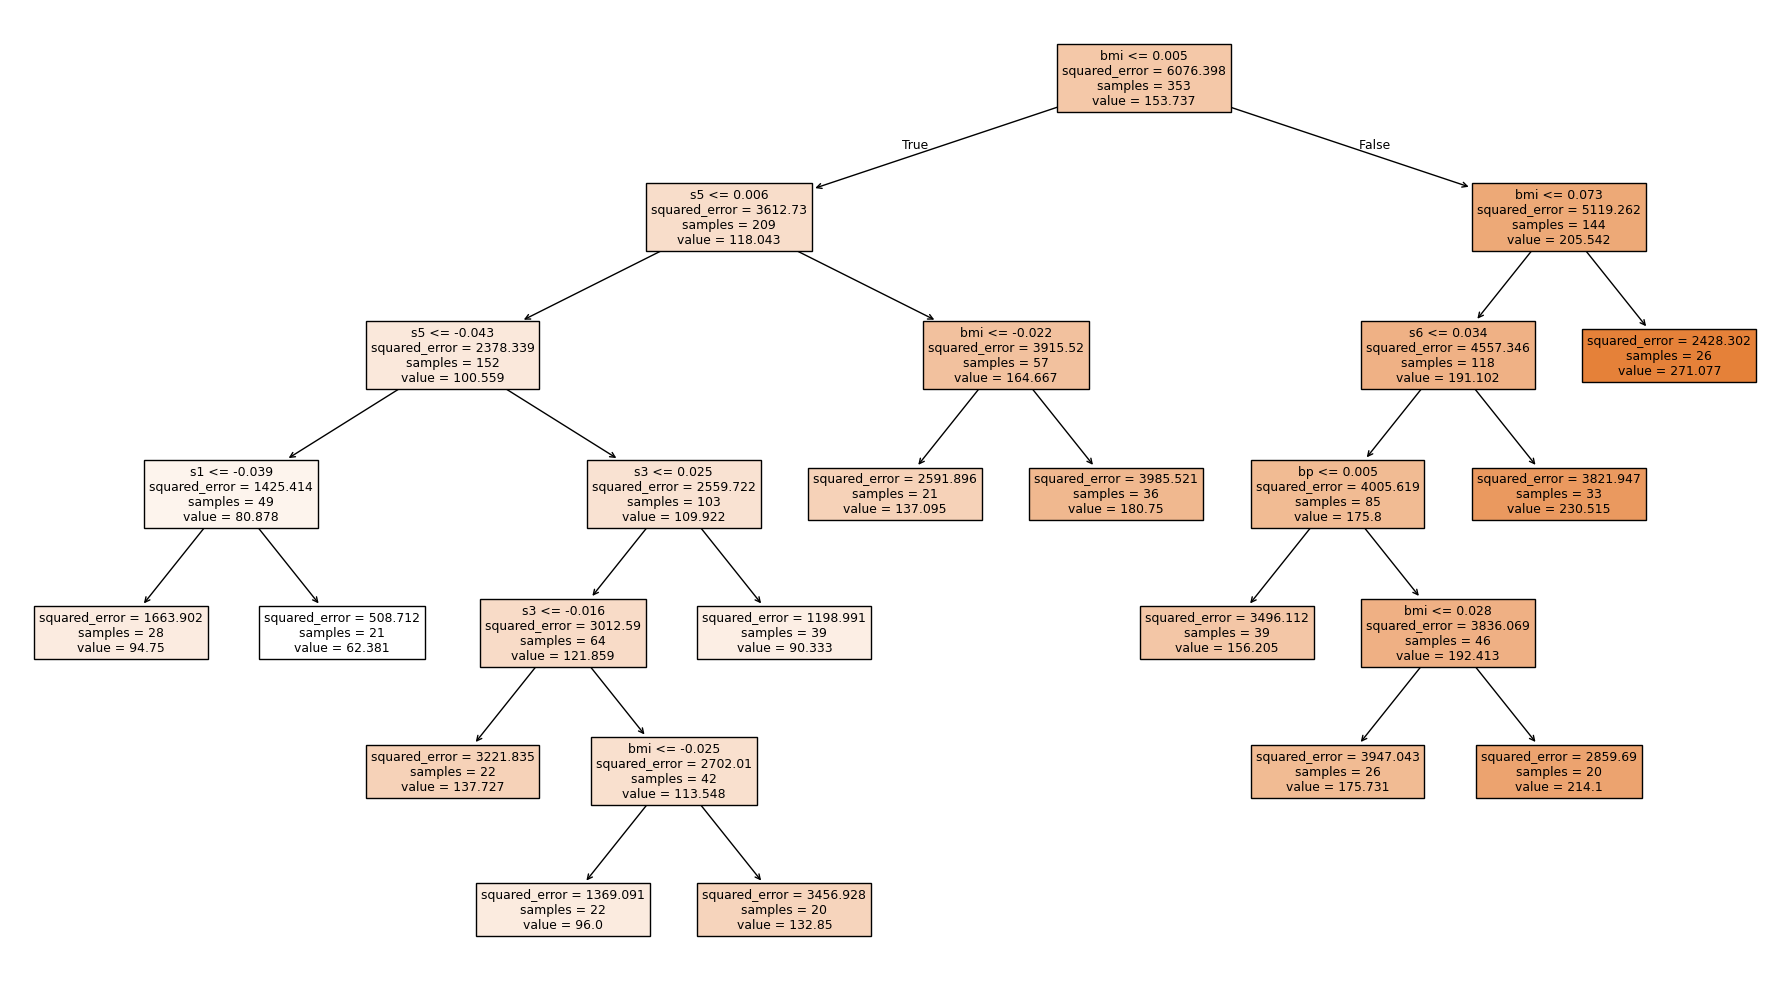

In [32]:
# plot graph


from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    regressor,
    feature_names=x.columns,
    filled=True
)

plt.tight_layout()
plt.show()